In [784]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler 
from matplotlib import pyplot as plt
import seaborn as sns

In [785]:
dataSet= pd.read_csv('Titanic-Dataset (1).csv')

In [786]:
df = dataSet.copy()

In [787]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [788]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [789]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Data Cleaning

In [790]:
df.drop_duplicates(
    subset=None,
    keep='first',
    inplace=True,
    ignore_index=False
)

In [791]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**Вывод:** видим, что в датасете остуствуют дубликаты

Заполним мединными значениями пропуски в возрасте в зависимости от пола

In [792]:
med_m = df[df['Sex'] == 'male']['Age'].median()
med_w = df[df['Sex'] == 'female']['Age'].median()

In [793]:
df['Age'] = df.groupby('Sex')['Age'].transform(lambda x: x.fillna(x.median()))

Так как в описании датасета не было сказано, что пропуски в признаке 'Cabin' означает ее отсутсвие у билета, то удалим данный признак, по причине остуствия ~78% значений.  

In [794]:
df.drop('Cabin',axis=1,inplace=True)

In [795]:
df.drop('PassengerId',axis=1,inplace=True)

In [796]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


Заполним пропущенные значения признака 'Embarked' значением моды

In [797]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [798]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


## EDA

In [799]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,27.0,1,2,W./C. 6607,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


<Axes: xlabel='Age', ylabel='Density'>

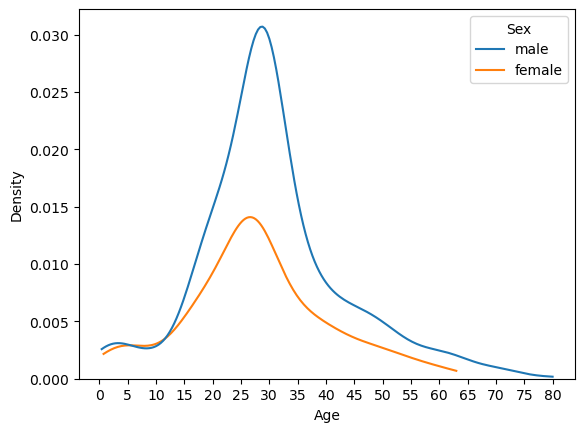

In [800]:
plt.xticks(np.arange(0, 85, 5))
sns.kdeplot(x='Age',data=df,hue='Sex',cut=0)

In [801]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Age'>

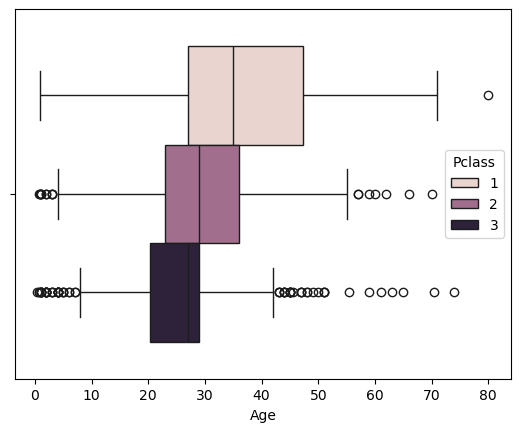

In [802]:
sns.boxplot(x='Age',data=df,hue='Pclass')

Заметим, что основная часть людей первого класса старше, чем второго и третьего

<Axes: xlabel='Survived', ylabel='count'>

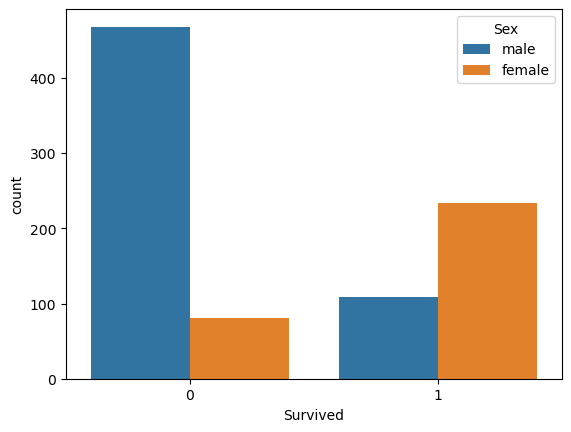

In [803]:
sns.countplot(x='Survived',data=df,hue='Sex')

Заметим, что погибших мужчин во много раз больше чем выживших, а среди выживщих женщин почти в два раза больше

In [804]:
print('Погибшие')
print(df[df['Survived'] == 0]['Sex'].value_counts())
print('Выжившие')
print(df[df['Survived'] == 1]['Sex'].value_counts())

Погибшие
Sex
male      468
female     81
Name: count, dtype: int64
Выжившие
Sex
female    233
male      109
Name: count, dtype: int64


<Axes: xlabel='Age', ylabel='Count'>

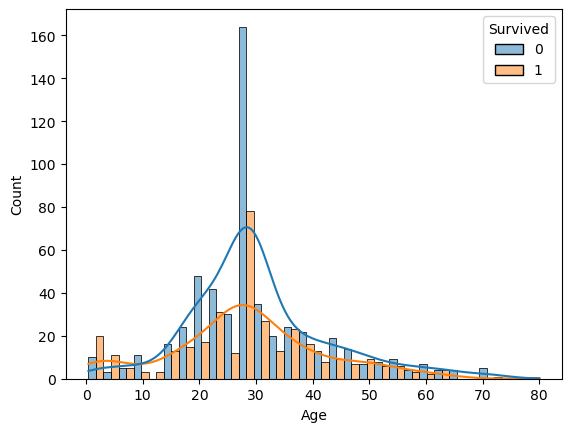

In [805]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='dodge', kde=True)

**Вывод:** група выживщих людей до 10 лет преобладает в отличии от погибших. 

<Axes: xlabel='Survived', ylabel='count'>

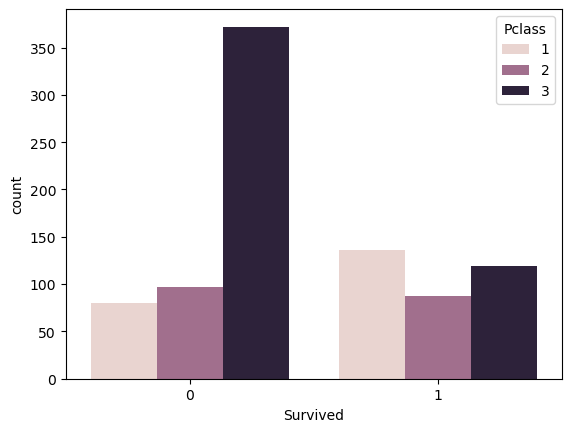

In [806]:
sns.countplot(x='Survived',data=df,hue='Pclass')

Из графика видно сильное классовое неравенство в значении выживаемости:

- 1-й класс: выжило больше, чем погибло

- 2-й класс: примерно поровну

- 3-й класс: погибло гораздо больше, чем выжило

<Axes: title={'center': 'Распределение пассажиров по портам посадки и классам'}, xlabel='Embarked', ylabel='count'>

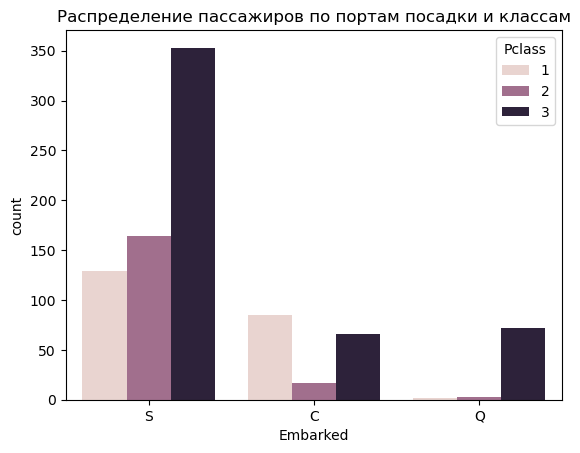

In [807]:
plt.title('Распределение пассажиров по портам посадки и классам')
sns.countplot(x='Embarked',data=df,hue='Pclass')

<Axes: title={'center': 'Выживаемость по полу и классу'}, xlabel='Sex', ylabel='Pclass'>

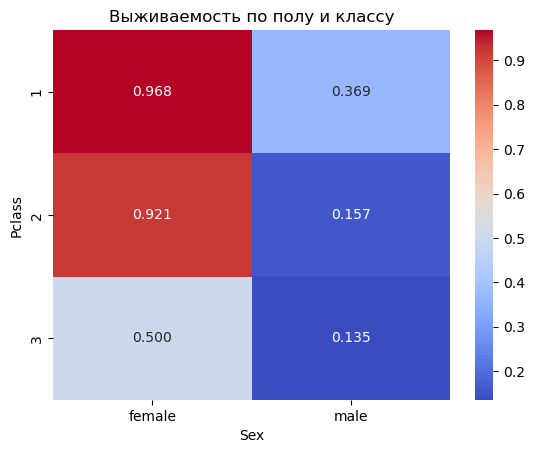

In [808]:
pv = df.pivot_table(index='Pclass', columns='Sex', values='Survived', aggfunc='mean')
plt.title('Выживаемость по полу и классу')
sns.heatmap(pv, annot=True, fmt='.3f', cmap='coolwarm',)

## Feature engineering 

Попробуем создать новые признаки, затем посмотрим на моделях, как она будем вести себя с ними и без них, скорее всего будет риск переобучения модели

In [809]:
df['Family_size'] = df['SibSp'] + df['Parch'] + 1

In [810]:
df.drop('SibSp',axis=1,inplace=True)
df.drop('Parch',axis=1,inplace=True)

In [811]:
df['Status'] = df['Name'].apply(lambda  x: x.split(',')[1].split('.')[0])

In [812]:
df.drop('Name',axis=1,inplace=True)

In [813]:
df['Ticket_group_size'] = df.groupby('Ticket')['Ticket'].transform('count')

In [814]:
df.drop('Ticket',axis=1,inplace=True)

In [815]:
def simplify_status(status):
    
    if status in ['Mrs', 'Miss', 'Ms', 'Mme', 'Mlle', 'Lady', 'the Countess']:
        return 'female'
    
    elif status == 'Master':
        return 'child'
    
    elif status in ['Mr', 'Rev', 'Dr', 'Major', 'Col', 'Capt', 'Sir', 'Don', 'Jonkheer']:
        return 'male'
    
    else:
        return 'rare'

In [816]:
df['Status'] = df['Status'].str.strip()
df['Status_group'] = df['Status'].apply(simplify_status)

In [817]:
df

,Survived,Pclass,Sex,Age,Fare,Embarked,Family_size,Status,Ticket_group_size,Status_group
0,0,3,male,22.0,7.2500,S,2,Mr,1,male
1,1,1,female,38.0,71.2833,C,2,Mrs,1,female
2,1,3,female,26.0,7.9250,S,1,Miss,1,female
3,1,1,female,35.0,53.1000,S,2,Mrs,2,female
4,0,3,male,35.0,8.0500,S,1,Mr,1,male
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,13.0000,S,1,Rev,1,male
887,1,1,female,19.0,30.0000,S,1,Miss,1,female
888,0,3,female,27.0,23.4500,S,4,Miss,2,female
889,1,1,male,26.0,30.0000,C,1,Mr,1,male


### Описание новых признаков

- **Family_size**: количество членов семьи, включая самого пассажира (SibSp + Parch)


- **Status**: статус (Mr., Mrs. и т.д.)

  
- **Ticket_group_size**: количество людей с одинаковым номером билета

- **Status_group**: статус пассажира (female,male,child,rare)

<Axes: title={'center': 'Выживаемость по наличии группы'}, xlabel='Survived', ylabel='count'>

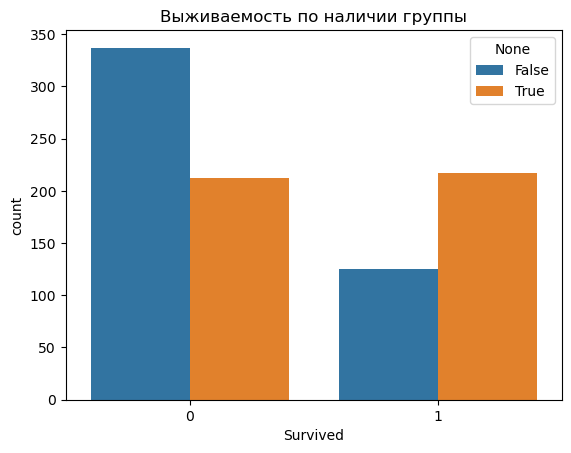

In [818]:
plt.title('Выживаемость по наличии группы')
sns.countplot(x = 'Survived',data=df,hue = (df['Family_size'] > 1) | (df['Ticket_group_size'] > 1))

Можно заметить, что основная группа погибших людей путешествовала в одиночку, а выжившие были в группах

**посмотреть сколько людей путешествовали по одному билету но не семьями**

## Model Training

In [819]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.impute import SimpleImputer

In [820]:
ordinal_cols = ['Pclass']
categorical_cols = ['Sex','Embarked']
numeric_cols = ['Age','Fare']

In [821]:
def fAge(X):
    X = X.copy()
    X['Age'] = X.groupby('Sex')['Age'].transform(lambda x: x.fillna(x.median()))
    return X

In [822]:
def fFare(X):
    X = X.copy()
    X['Fare'] = X.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))
    return X

In [823]:
def add_family_size(X):
    X = X.copy()
    X['Family_size'] = X['SibSp'] + X['Parch'] + 1
    return X

In [824]:
def add_status(X):
    X = X.copy()
    X['Status'] = X['Name'].apply(lambda x: x.split(',')[1].split('.')[0].strip())
    return X

In [825]:
fill_age = FunctionTransformer(fAge)

In [826]:
fill_fare = FunctionTransformer(fFare)

In [827]:
dataSet

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [828]:
y = dataSet['Survived']
X = dataSet.copy()
X.drop('Survived',axis=1,inplace=True)

In [829]:
drop_feat = ['PassengerId','Name','Ticket','Cabin']

In [830]:
preprocess = ColumnTransformer([
    ('drop','drop',drop_feat),
    ('fill_age',fill_age,['Age','Sex']),
    ('fill_fare',fill_fare,['Fare','Pclass'])
],remainder='passthrough')

In [831]:
pipeline_fe = Pipeline([
    ('family_size',FunctionTransformer(add_family_size)),
    ('add_status',FunctionTransformer(add_status))
])

In [834]:
pipeline = Pipeline([
    ('fe',pipeline_fe),
    ('preprocess',preprocess),
])

In [838]:
models = {
    'Logistic_Regression': P
}

1. логистическая регрессия
2. KNN
3. дерево решений
4. градиентный бустинг
5. случайный лес
6. остальны ансамбли